In [4]:
import csv
import numpy as np
import matplotlib.pyplot as plt
import copy
import math
import keras
import pandas as pd
import xgboost as xgb
from scipy.stats import norm
import os

from keras.models import Sequential
from keras.layers import Dense, BatchNormalization, Dropout
from keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import roc_auc_score


In [5]:
XGBoost_distances_all_data = []

Number of events: 20000
X shape: (20000, 16)
y shape: (20000, 2)
X coordinate range: -33.9984 to 33.9977
Y coordinate range: -33.9965 to 33.9973
Average XGBoost Delta X (mm): -0.0010173802495470896
Median XGBoost Delta X (mm): 0.0007253007507314058
Average XGBoost Delta Y (mm): -0.0029328256963848
Median XGBoost Delta Y (mm): -0.001780281428146551


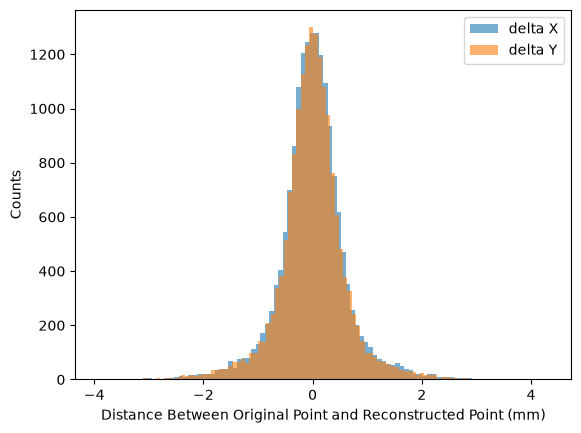

Number of events: 20000
X shape: (20000, 16)
y shape: (20000, 2)
X coordinate range: -33.9967 to 33.998
Y coordinate range: -33.999 to 33.9999
Average XGBoost Delta X (mm): 0.00590438893013268
Median XGBoost Delta X (mm): 0.0014474720001231844
Average XGBoost Delta Y (mm): -0.002046768018634372
Median XGBoost Delta Y (mm): -0.002196784210205048


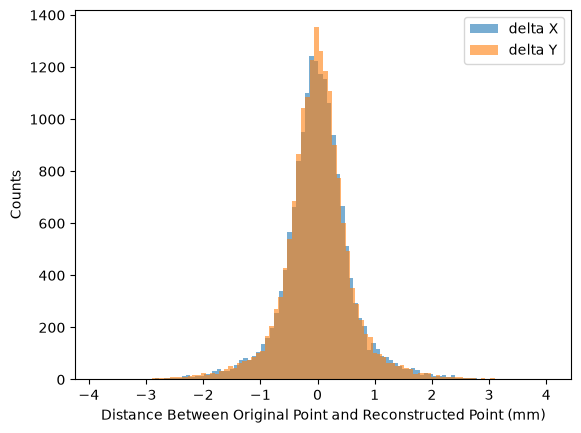

Number of events: 100000
X shape: (100000, 16)
y shape: (100000, 2)
X coordinate range: -33.9994 to 33.9998
Y coordinate range: -33.9982 to 33.9999
Average XGBoost Delta X (mm): 0.0008269821523269688
Median XGBoost Delta X (mm): 0.001706840366363683
Average XGBoost Delta Y (mm): -8.661259819083996e-05
Median XGBoost Delta Y (mm): -0.0016639266967775623


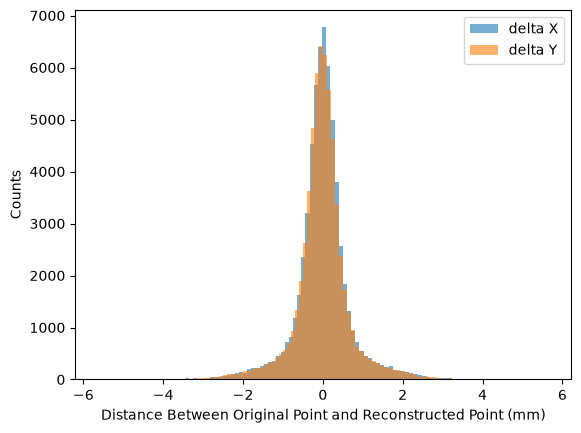

Number of events: 20000
X shape: (20000, 16)
y shape: (20000, 2)
X coordinate range: -33.9973 to 33.9983
Y coordinate range: -33.9989 to 33.9948
Average XGBoost Delta X (mm): 0.0021678578718680053
Median XGBoost Delta X (mm): -0.0024123405456542395
Average XGBoost Delta Y (mm): -5.642343966184915e-05
Median XGBoost Delta Y (mm): -1.0130310058510672e-05


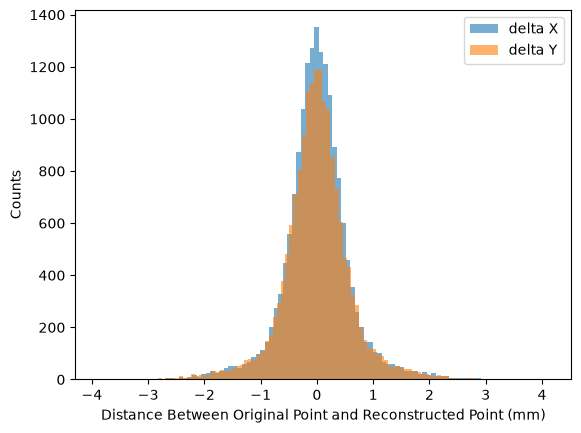

Number of events: 20000
X shape: (20000, 16)
y shape: (20000, 2)
X coordinate range: -33.9985 to 33.9957
Y coordinate range: -33.9968 to 33.9968
Average XGBoost Delta X (mm): 0.0026513523859571873
Median XGBoost Delta X (mm): 0.0001376459503175558
Average XGBoost Delta Y (mm): -0.003338665028675029
Median XGBoost Delta Y (mm): -0.0010075752258284464


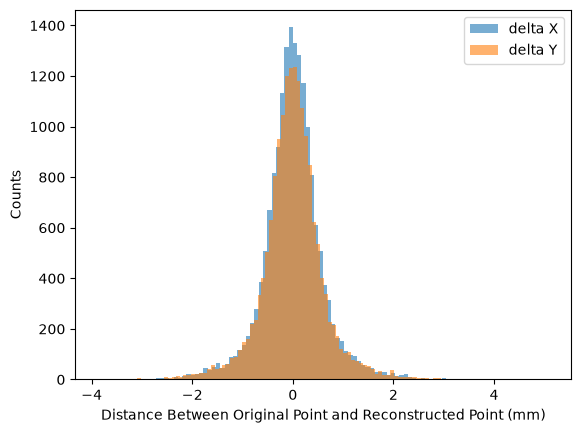

Number of events: 20000
X shape: (20000, 16)
y shape: (20000, 2)
X coordinate range: -33.9997 to 33.9998
Y coordinate range: -33.9981 to 33.9999
Average XGBoost Delta X (mm): 0.0028717452296151283
Median XGBoost Delta X (mm): 0.0019339489746101868
Average XGBoost Delta Y (mm): 0.00043003464233095013
Median XGBoost Delta Y (mm): 0.00220952682495187


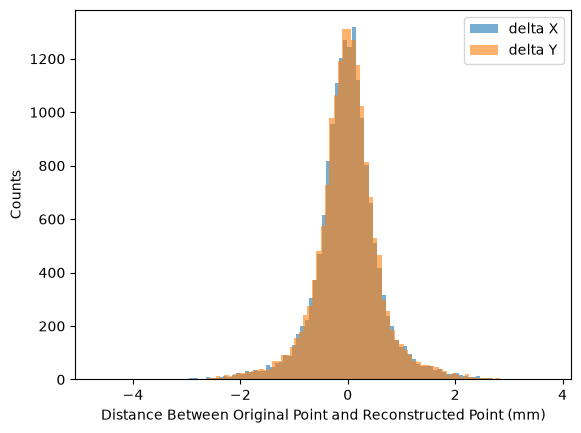

Number of events: 20000
X shape: (20000, 16)
y shape: (20000, 2)
X coordinate range: -33.9967 to 33.9993
Y coordinate range: -33.9892 to 33.999
Average XGBoost Delta X (mm): -0.00048243927638415355
Median XGBoost Delta X (mm): 0.0013783954620361465
Average XGBoost Delta Y (mm): -0.004397922633426423
Median XGBoost Delta Y (mm): -0.004952579421998002


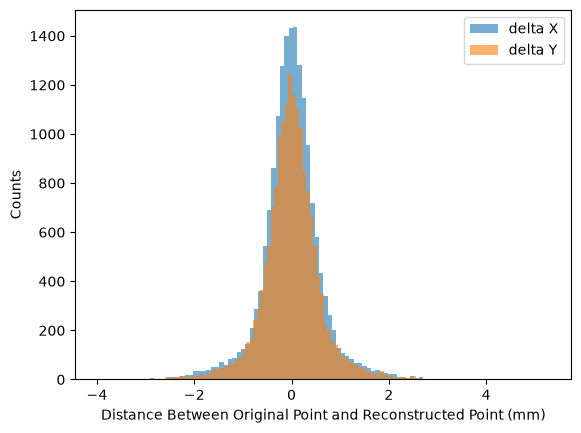

Number of events: 20000
X shape: (20000, 16)
y shape: (20000, 2)
X coordinate range: -33.9988 to 33.9957
Y coordinate range: -33.9898 to 33.9964
Average XGBoost Delta X (mm): -0.0010661191117193587
Median XGBoost Delta X (mm): -0.00145818181915245
Average XGBoost Delta Y (mm): 0.002846909547337737
Median XGBoost Delta Y (mm): -6.727098464969807e-05


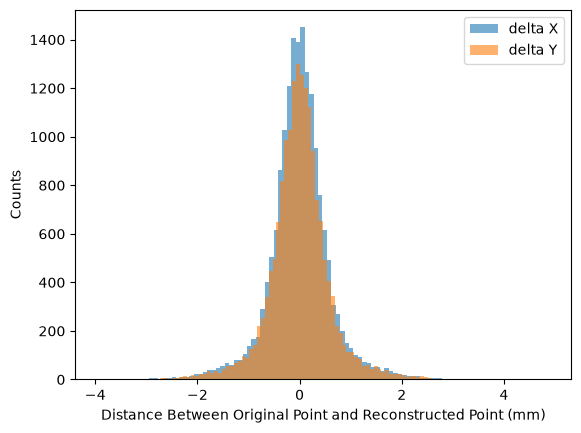

Number of events: 20000
X shape: (20000, 16)
y shape: (20000, 2)
X coordinate range: -33.9939 to 33.9976
Y coordinate range: -33.9962 to 33.9895
Average XGBoost Delta X (mm): 0.0002499530869808887
Median XGBoost Delta X (mm): 0.002033204898833508
Average XGBoost Delta Y (mm): 0.005664649351823801
Median XGBoost Delta Y (mm): 0.007648834667206168


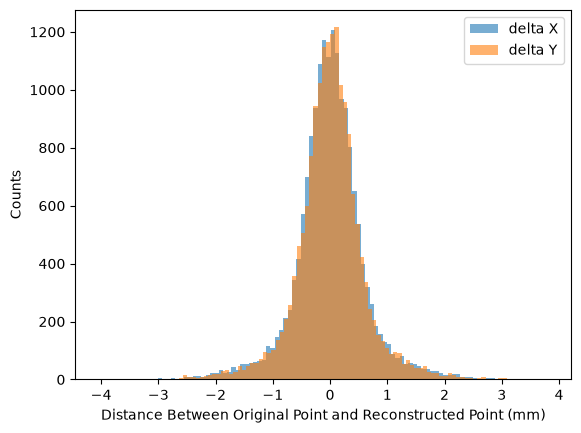

Number of events: 20000
X shape: (20000, 16)
y shape: (20000, 2)
X coordinate range: -33.9991 to 33.9929
Y coordinate range: -33.9979 to 33.999
Average XGBoost Delta X (mm): 0.0021475488009808905
Median XGBoost Delta X (mm): 0.003420717620848994
Average XGBoost Delta Y (mm): 0.001158711029103889
Median XGBoost Delta Y (mm): 0.00141659803390484


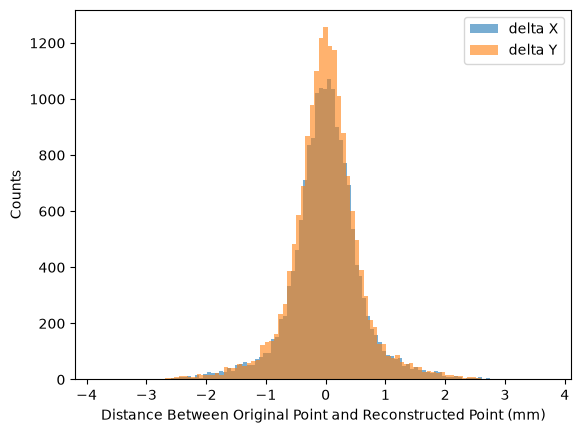

Number of events: 20000
X shape: (20000, 16)
y shape: (20000, 2)
X coordinate range: -33.9984 to 33.9939
Y coordinate range: -33.9982 to 33.9968
Average XGBoost Delta X (mm): 0.0001615044272699561
Median XGBoost Delta X (mm): 0.0019172225952146969
Average XGBoost Delta Y (mm): 0.0006597206568957291
Median XGBoost Delta Y (mm): -0.0006413593292230323


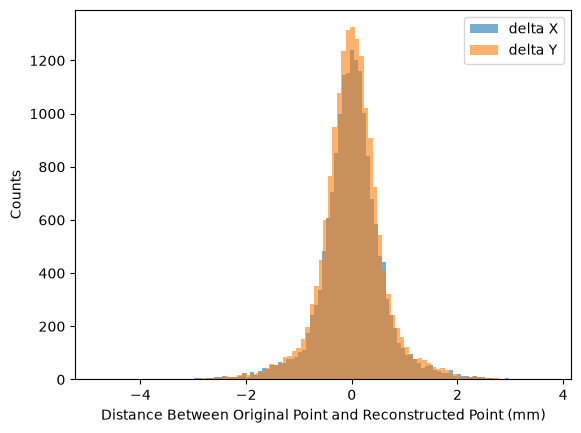

Number of events: 20000
X shape: (20000, 16)
y shape: (20000, 2)
X coordinate range: -33.9978 to 33.9999
Y coordinate range: -33.9978 to 33.9998
Average XGBoost Delta X (mm): 0.00046617660812366585
Median XGBoost Delta X (mm): 0.0013159582901006587
Average XGBoost Delta Y (mm): -0.003661088076057901
Median XGBoost Delta Y (mm): -0.0006723945617674015


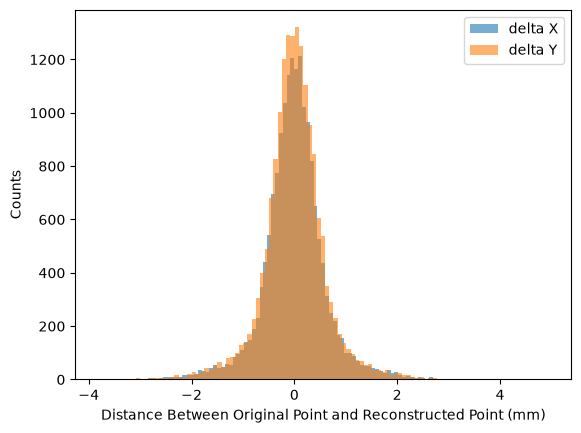

Number of events: 20000
X shape: (20000, 16)
y shape: (20000, 2)
X coordinate range: -33.9989 to 33.9988
Y coordinate range: -33.999 to 33.9959
Average XGBoost Delta X (mm): -0.002560193844955834
Median XGBoost Delta X (mm): 0.0008349956626892648
Average XGBoost Delta Y (mm): -0.000545151674819541
Median XGBoost Delta Y (mm): 0.004986391506195403


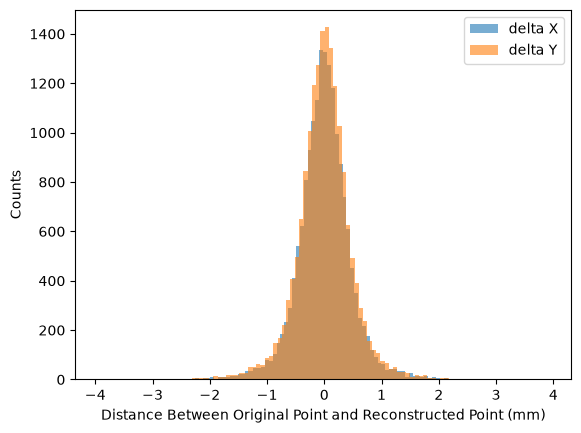

Number of events: 20000
X shape: (20000, 16)
y shape: (20000, 2)
X coordinate range: -33.9977 to 33.9996
Y coordinate range: -33.9919 to 33.9997
Average XGBoost Delta X (mm): -0.0005493377510928588
Median XGBoost Delta X (mm): -0.0006928077697747163
Average XGBoost Delta Y (mm): 0.0001829436011794726
Median XGBoost Delta Y (mm): -0.004473877716063874


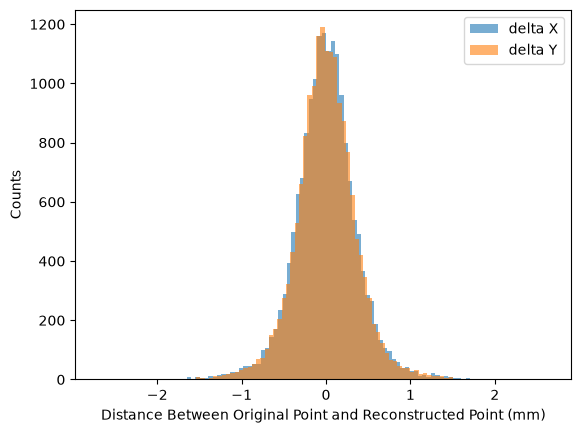

Number of events: 20000
X shape: (20000, 16)
y shape: (20000, 2)
X coordinate range: -33.9961 to 33.9983
Y coordinate range: -33.9981 to 33.9947
Average XGBoost Delta X (mm): -0.0009648145184909428
Median XGBoost Delta X (mm): -0.0018745994567865472
Average XGBoost Delta Y (mm): -0.0010028203304558519
Median XGBoost Delta Y (mm): -0.0023423477172841017


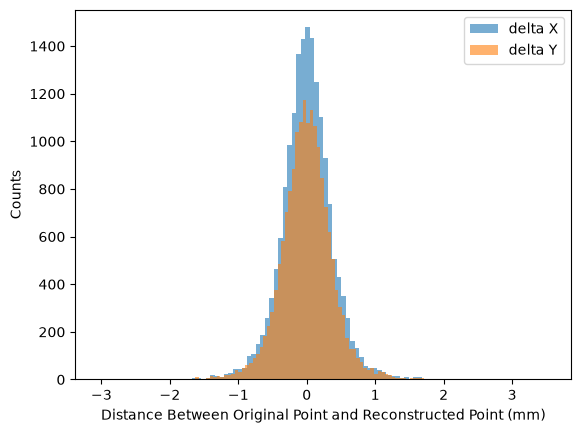

Number of events: 20000
X shape: (20000, 16)
y shape: (20000, 2)
X coordinate range: -33.9905 to 33.9934
Y coordinate range: -33.9881 to 33.9954
Average XGBoost Delta X (mm): 0.0013704431344053831
Median XGBoost Delta X (mm): 0.000950817871093794
Average XGBoost Delta Y (mm): -0.0017764740109527041
Median XGBoost Delta Y (mm): -0.0035688415527331853


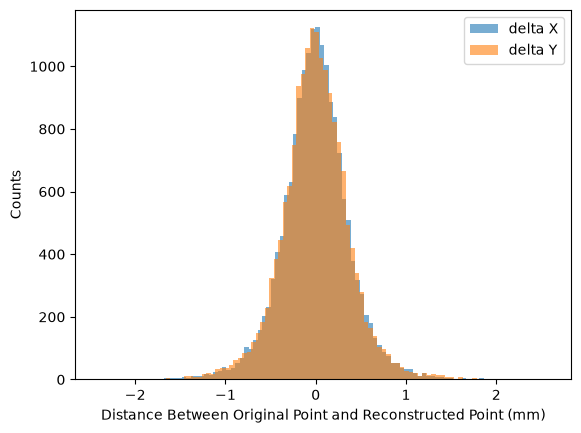

Number of events: 20000
X shape: (20000, 16)
y shape: (20000, 2)
X coordinate range: -33.9999 to 33.9994
Y coordinate range: -33.9928 to 33.9946
Average XGBoost Delta X (mm): -0.0006184302517675038
Median XGBoost Delta X (mm): -0.0028590211486812477
Average XGBoost Delta Y (mm): -8.354643783062884e-05
Median XGBoost Delta Y (mm): 0.0011707802200325982


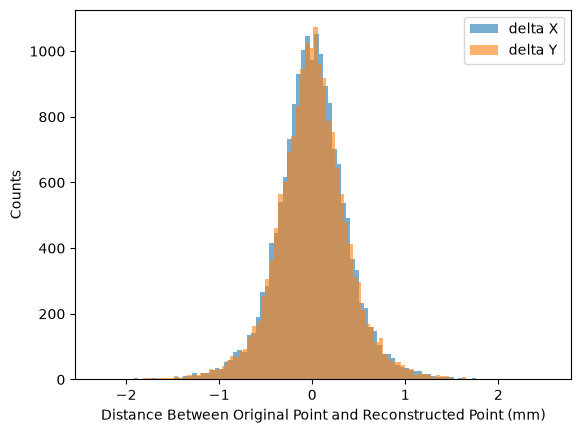

Number of events: 20000
X shape: (20000, 16)
y shape: (20000, 2)
X coordinate range: -33.9903 to 33.9981
Y coordinate range: -33.9983 to 33.9963
Average XGBoost Delta X (mm): -0.0016514637523096782
Median XGBoost Delta X (mm): 0.00132408439636187
Average XGBoost Delta Y (mm): -0.000951886785714534
Median XGBoost Delta Y (mm): -0.0017488954925536154


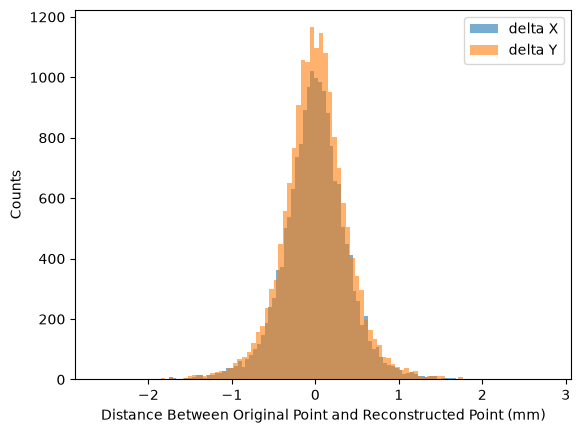

Number of events: 20000
X shape: (20000, 16)
y shape: (20000, 2)
X coordinate range: -33.9986 to 33.9986
Y coordinate range: -34.0 to 33.999
Average XGBoost Delta X (mm): 0.0004970799145899377
Median XGBoost Delta X (mm): 0.0016935409545894217
Average XGBoost Delta Y (mm): 0.001538868694782084
Median XGBoost Delta Y (mm): -0.0005582077026381992


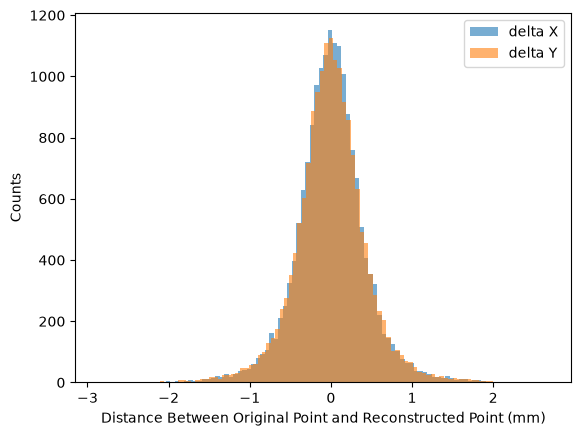

Number of events: 20000
X shape: (20000, 16)
y shape: (20000, 2)
X coordinate range: -33.9989 to 33.9831
Y coordinate range: -33.9999 to 33.9992
Average XGBoost Delta X (mm): -0.0030031880923700447
Median XGBoost Delta X (mm): -0.0019907633972174256
Average XGBoost Delta Y (mm): -0.00023135665647574843
Median XGBoost Delta Y (mm): -3.0146789550766773e-05


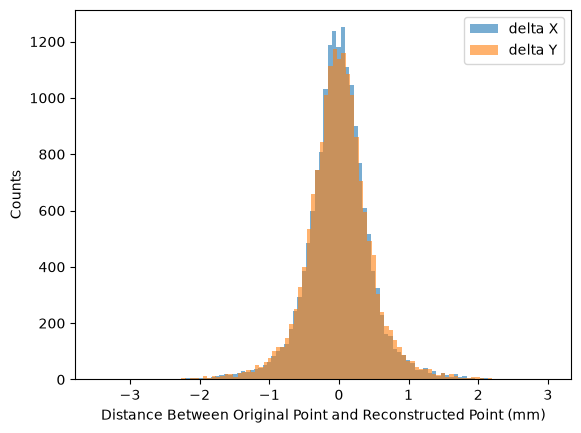

In [6]:
numbers = [3.05, 4.05, 5.05, 6.05, 7.05,8.05, 9.05, 10.05, 11.05, 12.05,13.05, 14.05, 15.05, 16.05, 17.05, 18.05, 19.05, 20.05, 25.05, 40.05]

for q in numbers:
    file_path = os.path.join('/Users/judyz/Desktop/PET-4x4/build',f'{q}mm',f'{q}mm.csv')

    file = open(file_path)
    csvreader = csv.reader(file)

    original_X = []
    original_y = []

    line_count = 0

    for row in csvreader:
        if line_count >= 1:
            original_X.append([int(i) for i in row[1:17]])
            original_y.append([float(row[17]),float(row[18])])
        line_count += 1

    file.close()

    X = np.array(original_X)
    y = np.array(original_y)

    print("Number of events:", len(X))
    print("X shape:", X.shape)
    print("y shape:", y.shape)
    print("X coordinate range:",np.min(y[:, 0]),"to",np.max(y[:, 0]))
    print("Y coordinate range:",np.min(y[:, 1]),"to",np.max(y[:, 1]))

    XGBoost_distances = np.zeros((331, 331, 2))

    scaler = StandardScaler()

    for k in range(10):

        X_XGBoost = scaler.fit_transform(X)
        X_train, X_val, y_train, y_val = train_test_split(X_XGBoost,y,test_size=0.3)

        model = xgb.XGBRegressor()
        model.fit(X_train,y_train)

        yhat = model.predict(X_XGBoost)


        for i in range(len(X)):
            x_index = (165+round(y[i][0] * 5))
            y_index = (165-round(y[i][1] * 5))
            if (0 <= x_index < 331 and 0 <= y_index < 331):
                delta_x = (yhat[i][0] - y[i][0])
                XGBoost_distances[x_index,y_index,0]= (k / (k + 1)*XGBoost_distances[x_index, y_index,0] + 1 / (k + 1)*delta_x)
                delta_y = (yhat[i][1]-y[i][1])
                XGBoost_distances[x_index,y_index,1]= (k / (k + 1)*XGBoost_distances[x_index, y_index,1] + 1 / (k + 1)*delta_y)  

    delta_x_nonzero = XGBoost_distances[:, :, 0]
    delta_x_nonzero = delta_x_nonzero[delta_x_nonzero != 0]
    delta_y_nonzero = XGBoost_distances[:, :, 1]
    delta_y_nonzero = delta_y_nonzero[delta_y_nonzero != 0]

    print("Average XGBoost Delta X (mm): " + str(np.average(delta_x_nonzero)))     
    print("Median XGBoost Delta X (mm): " + str(np.median(delta_x_nonzero)))
    print("Average XGBoost Delta Y (mm): " + str(np.average(delta_y_nonzero)))     
    print("Median XGBoost Delta Y (mm): " + str(np.median(delta_y_nonzero)))

    plt.figure()
    plt.hist(delta_x_nonzero,bins=100,alpha=0.6,label='delta X')
    plt.hist(delta_y_nonzero,bins=100,alpha=0.6,label='delta Y')
    plt.xlabel('Distance Between Original Point and Reconstructed Point (mm)')
    plt.ylabel('Counts')
    plt.legend(loc='upper right')
    plt.show()

    XGBoost_distances_all_data.append(XGBoost_distances)

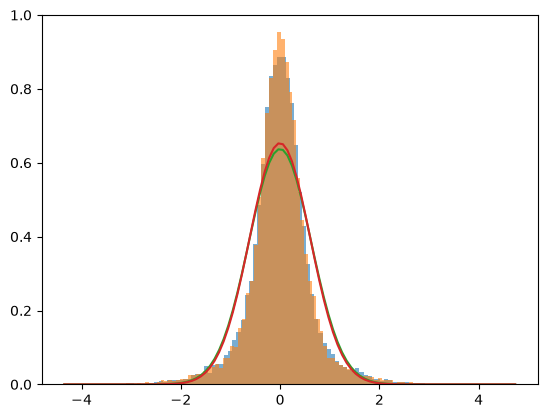

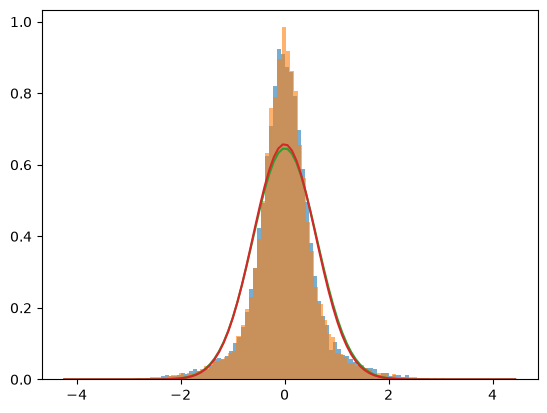

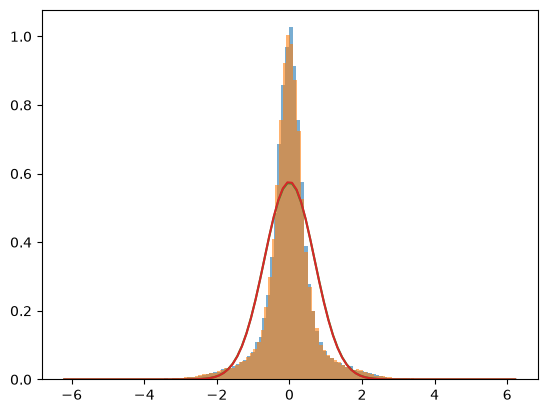

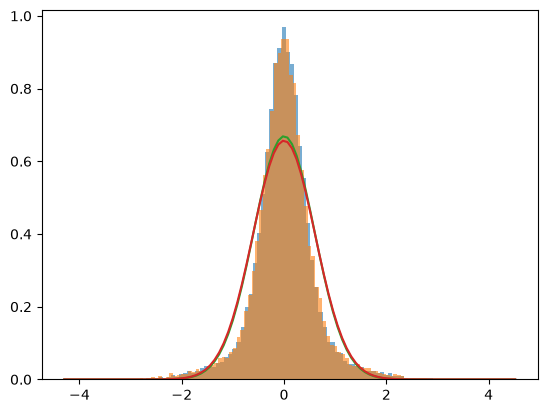

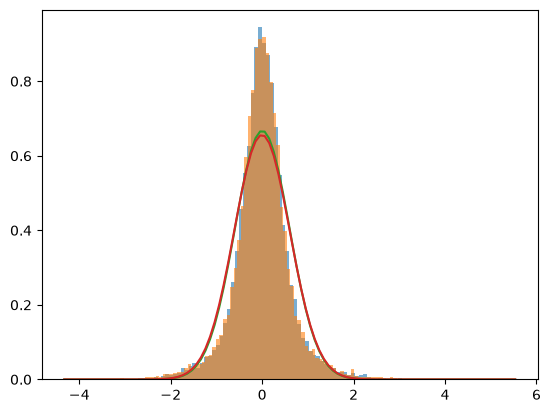

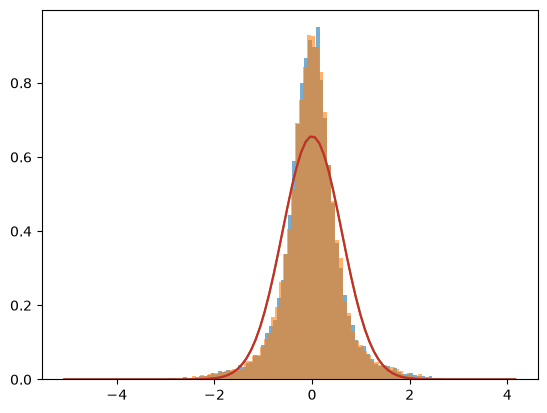

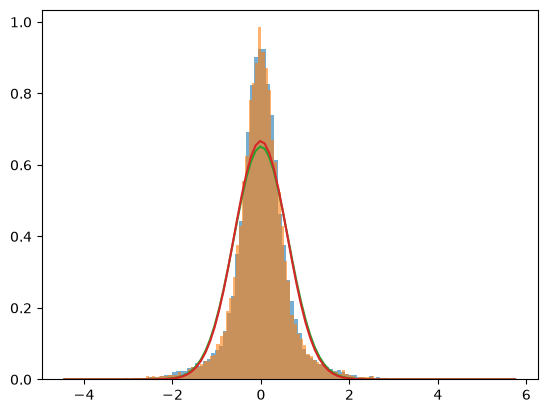

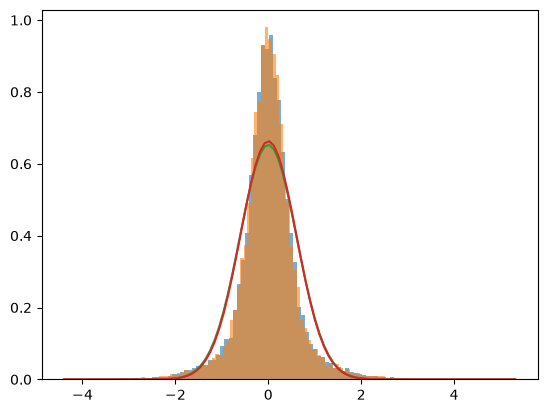

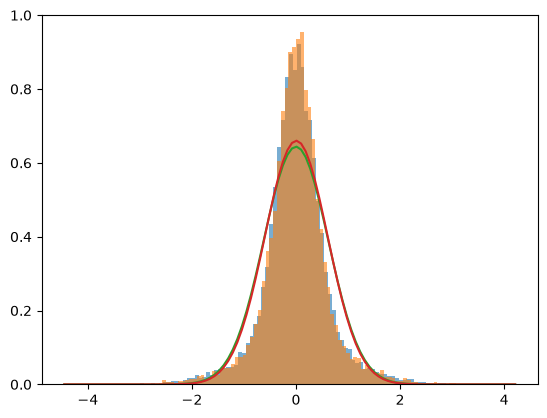

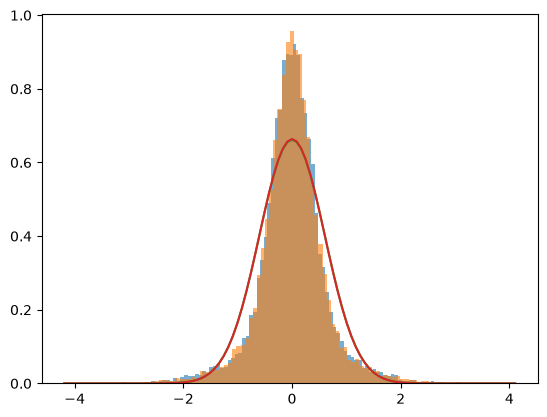

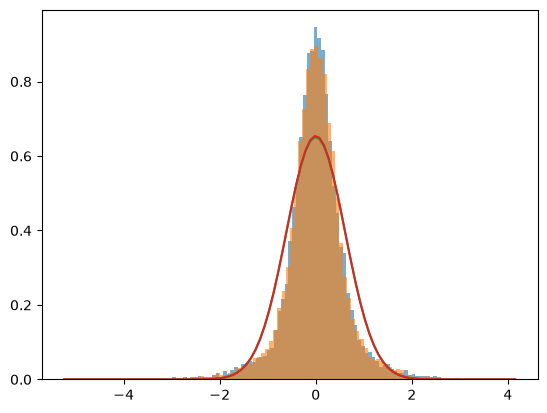

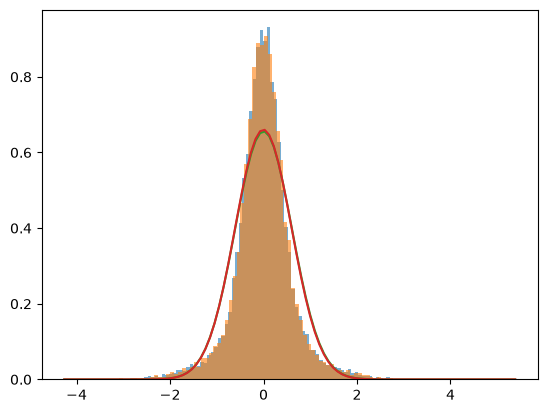

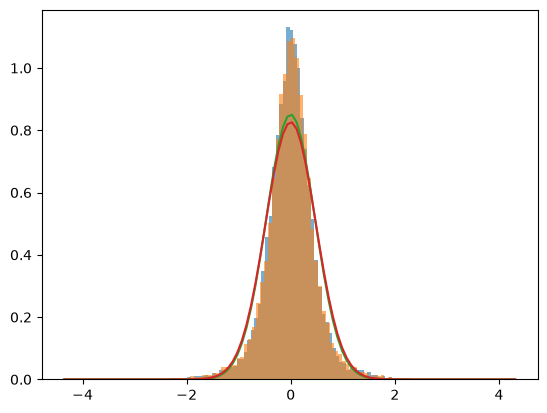

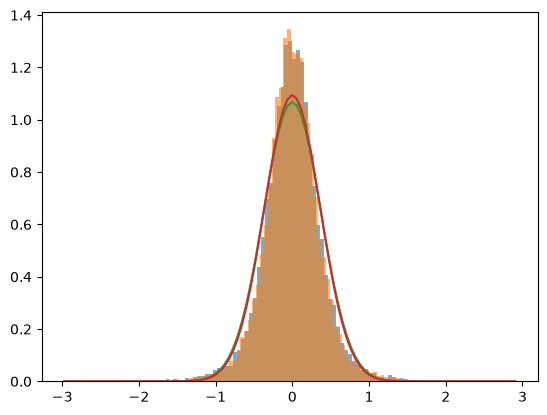

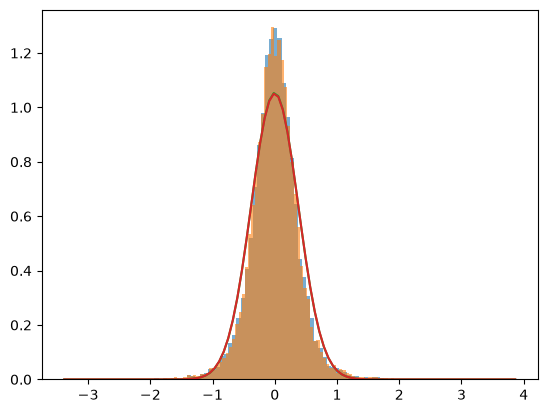

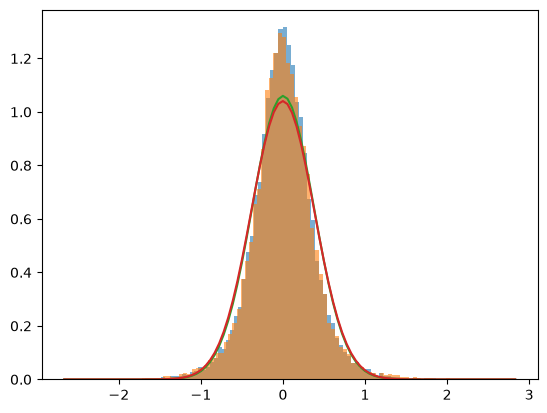

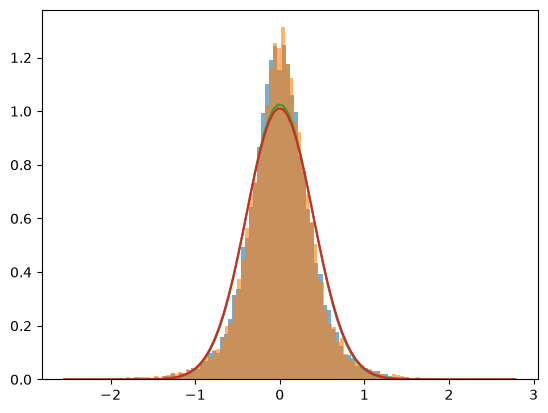

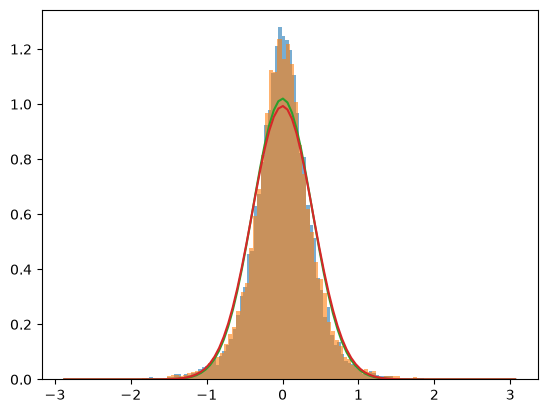

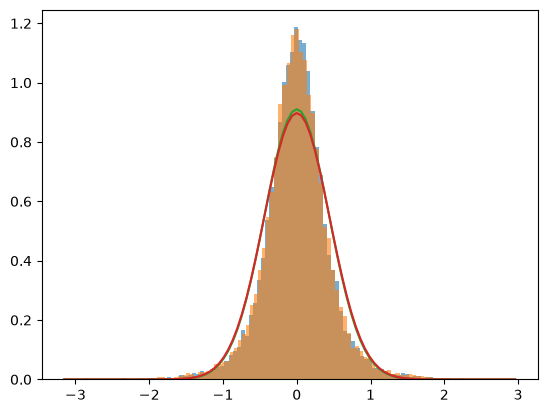

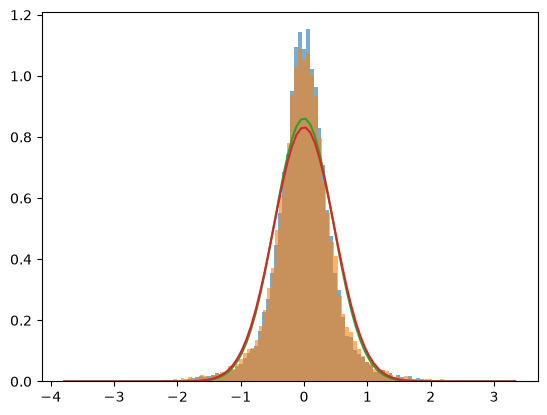

In [7]:
standard_deviations = []
means = []


for element in XGBoost_distances_all_data:

    delta_x = element[:, :, 0]
    delta_x = delta_x[delta_x != 0]

    delta_y = element[:, :, 1]
    delta_y = delta_y[delta_y != 0]

    meanx,stdx=norm.fit(delta_x)
    meany,stdy=norm.fit(delta_y)

    standard_deviations.append([stdx, stdy])
    means.append([meanx, meany])

    plt.hist(delta_x,bins=100,alpha=0.6,label='delta X',density=True)
    plt.hist(delta_y,bins=100,alpha=0.6,label='delta Y',density=True)

    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 100)
    xy = norm.pdf(x, meanx, stdx)
    yy = norm.pdf(x, meany, stdy)

    plt.plot(x, xy)
    plt.plot(x, yy)
    plt.show()

In [8]:

print([standard_deviations[9][0]*2.355, standard_deviations[9][1]*2.355])
print([standard_deviations[9][0],standard_deviations[9][1]])

XGBoost_distances_all_data_np = np.array(XGBoost_distances_all_data)

np.savetxt('XGBoost_distances_delta.csv',XGBoost_distances_all_data_np.reshape(XGBoost_distances_all_data_np.shape[0],-1    
    )
)

print(np.array(XGBoost_distances_all_data).shape)
print(np.array(XGBoost_distances_all_data).size)

[np.float64(1.4193086514013231), np.float64(1.4155624092885344)]
[np.float64(0.6026788328668039), np.float64(0.601088071884728)]
(20, 331, 331, 2)
4382440
